In [4]:
import sys
sys.path.append("..")
import os
import requests
from dotenv import load_dotenv

# carichiamo la chiave TMDB
load_dotenv("../.env")
api_key = os.getenv("TMDB_API_KEY")
print("Chiave caricata:", api_key[:6], "...")

# la lista dei film d'autore che vogliamo analizzare
film_autore = [
    "The Florida Project",
    "All These Sleepless Nights",
    "The Worst Person in the World",
    "American Honey",
    "Fish Tank",
    "Mommy",
    "Laurence Anyways",
    "The Elephant Man",
    "Eternal Sunshine of the Spotless Mind",
]

print("Film da analizzare:", len(film_autore))

Chiave caricata: cecade ...
Film da analizzare: 9


In [5]:
# per ogni film cerchiamo su TMDB e prendiamo il link del trailer
risultati_autore = []

for titolo in film_autore:
    # 1. cerchiamo il film per titolo
    url_search = "https://api.themoviedb.org/3/search/movie"
    params = {"api_key": api_key, "query": titolo}
    r = requests.get(url_search, params=params)
    risultati = r.json()["results"]

    if not risultati:
        print("NON trovato:", titolo)
        continue

    # prendiamo il primo risultato (il piu rilevante)
    film = risultati[0]
    tmdb_id = film["id"]
    anno = film.get("release_date", "")

In [6]:
print("Film salvati:", len(risultati_autore))
for r in risultati_autore:
    print(r["titolo"], "-", r["anno"], "-", "trailer si" if r["trailer_link"] else "trailer NO")

Film salvati: 0


In [7]:
titolo = "The Florida Project"

url_search = "https://api.themoviedb.org/3/search/movie"
params = {"api_key": api_key, "query": titolo}
r = requests.get(url_search, params=params)

print("Status code:", r.status_code)
print("Risposta:", r.json())

Status code: 200
Risposta: {'page': 1, 'results': [{'adult': False, 'backdrop_path': '/GOwNU7Z9G3ORjNxdZnURfuIGS6.jpg', 'genre_ids': [18], 'id': 394117, 'title': 'The Florida Project', 'original_language': 'en', 'original_title': 'The Florida Project', 'overview': 'The story of a precocious six year-old and her ragtag group of friends whose summer break is filled with childhood wonder, possibility and a sense of adventure while the adults around them struggle with hard times.', 'popularity': 10.757, 'poster_path': '/5QnDxdJg1fi6uMSkSi4x8tHsltm.jpg', 'release_date': '2017-10-06', 'softcore': False, 'video': False, 'vote_average': 7.428, 'vote_count': 3161}, {'adult': False, 'backdrop_path': '/sU6UUpT9TEgTo776zOO6ua8lfHg.jpg', 'genre_ids': [99], 'id': 605931, 'title': 'Under the Rainbow: Making The Florida Project', 'original_language': 'en', 'original_title': 'Under the Rainbow: Making The Florida Project', 'overview': 'An interesting featurette which has some good behind the scenes foo

In [8]:
risultati_autore = []

for titolo in film_autore:
    try:
        # cerca il film
        url_search = "https://api.themoviedb.org/3/search/movie"
        params = {"api_key": api_key, "query": titolo}
        r = requests.get(url_search, params=params)
        risultati = r.json()["results"]

        if not risultati:
            print("NON trovato:", titolo)
            continue

        film = risultati[0]
        tmdb_id = film["id"]
        anno = film.get("release_date", "")[:4]

        # cerca il trailer
        url_videos = f"https://api.themoviedb.org/3/movie/{tmdb_id}/videos"
        r = requests.get(url_videos, params={"api_key": api_key})
        video = r.json()["results"]

        link = None
        for v in video:
            if v["type"] == "Trailer" and v["site"] == "YouTube":
                link = "https://www.youtube.com/watch?v=" + v["key"]
                break

        risultati_autore.append({
            "titolo": titolo,
            "anno": anno,
            "tmdb_id": tmdb_id,
            "trailer_link": link,
        })
        print(f"OK: {titolo} ({anno}) - trailer: {'si' if link else 'NO'}")

    except Exception as e:
        print(f"ERRORE su {titolo}: {e}")

print("\nFilm salvati:", len(risultati_autore))

OK: The Florida Project (2017) - trailer: si
OK: All These Sleepless Nights (2016) - trailer: si
OK: The Worst Person in the World (2021) - trailer: si
OK: American Honey (2016) - trailer: si
OK: Fish Tank (2009) - trailer: si
OK: Mommy (2026) - trailer: si
OK: Laurence Anyways (2012) - trailer: si
OK: The Elephant Man (1980) - trailer: si
OK: Eternal Sunshine of the Spotless Mind (2004) - trailer: si

Film salvati: 9


In [9]:
# controlliamo cosa ha trovato per Mommy
url_search = "https://api.themoviedb.org/3/search/movie"
params = {"api_key": api_key, "query": "Mommy"}
r = requests.get(url_search, params=params)

for film in r.json()["results"][:5]:
    print(film["title"], "-", film.get("release_date", "")[:4], "- id:", film["id"])

Sugar Mommy - 2026 - id: 1710886
Mommy - 2014 - id: 265177
Other Mommy - 2026 - id: 1400837
Goodnight Mommy - 2022 - id: 814800
Goodnight Mommy - 2015 - id: 284303


In [10]:
# Mommy aveva preso il film sbagliato: correggiamo con l'id di Dolan (2014)
mommy_id = 265177

# recuperiamo il trailer del Mommy giusto
url_videos = f"https://api.themoviedb.org/3/movie/{mommy_id}/videos"
r = requests.get(url_videos, params={"api_key": api_key})
video = r.json()["results"]

link = None
for v in video:
    if v["type"] == "Trailer" and v["site"] == "YouTube":
        link = "https://www.youtube.com/watch?v=" + v["key"]
        break

# aggiorniamo il record di Mommy nella lista
for film in risultati_autore:
    if film["titolo"] == "Mommy":
        film["anno"] = "2014"
        film["tmdb_id"] = mommy_id
        film["trailer_link"] = link

print("Mommy corretto - trailer:", "si" if link else "NO")

# ricontrolliamo tutta la lista
for film in risultati_autore:
    print(film["titolo"], "-", film["anno"], "-", "trailer si" if film["trailer_link"] else "trailer NO")

Mommy corretto - trailer: si
The Florida Project - 2017 - trailer si
All These Sleepless Nights - 2016 - trailer si
The Worst Person in the World - 2021 - trailer si
American Honey - 2016 - trailer si
Fish Tank - 2009 - trailer si
Mommy - 2014 - trailer si
Laurence Anyways - 2012 - trailer si
The Elephant Man - 1980 - trailer si
Eternal Sunshine of the Spotless Mind - 2004 - trailer si


In [11]:
import pandas as pd

# salviamo la lista come CSV
autore_df = pd.DataFrame(risultati_autore)
autore_df.to_csv("../data/source/auteur_films.csv", index=False)
print("Salvato:", len(autore_df), "film d'autore")
autore_df

Salvato: 9 film d'autore


,titolo,anno,tmdb_id,trailer_link
0,The Florida Project,2017,394117,https://www.youtube.com/watch?v=WwQ-NH1rRT4
1,All These Sleepless Nights,2016,376386,https://www.youtube.com/watch?v=toRRACvGp60
2,The Worst Person in the World,2021,660120,https://www.youtube.com/watch?v=gpkQgk1Fi1Q
3,American Honey,2016,340485,https://www.youtube.com/watch?v=y1SpWZm1PLc
4,Fish Tank,2009,24469,https://www.youtube.com/watch?v=xf5VOvB5MHA
5,Mommy,2014,265177,https://www.youtube.com/watch?v=PlZB2LLjzZY
6,Laurence Anyways,2012,110160,https://www.youtube.com/watch?v=Y-CX4bRqJzw
7,The Elephant Man,1980,1955,https://www.youtube.com/watch?v=kxb_1457gGs
8,Eternal Sunshine of the Spotless Mind,2004,38,https://www.youtube.com/watch?v=c2e-bj6qy8Y


In [12]:
import os
import yt_dlp

# cartella dedicata ai trailer d'autore
os.makedirs("../data/raw/auteur_trailers", exist_ok=True)

for film in risultati_autore:
    titolo = film["titolo"]
    link = film["trailer_link"]
    # nome file pulito: usiamo il tmdb_id
    output = f"../data/raw/auteur_trailers/{film['tmdb_id']}.mp4"

    if os.path.exists(output):
        print("gia scaricato:", titolo)
        continue

    opzioni = {
        "format": "best[height<=480]/best",
        "outtmpl": output,
        "extractor_args": {"youtube": {"player_client": ["android"]}},
        "quiet": True,
    }

    try:
        with yt_dlp.YoutubeDL(opzioni) as ydl:
            ydl.download([link])
        print("OK:", titolo)
    except Exception as e:
        print("FALLITO:", titolo)

Deprecated Feature: Support for Python version 3.9 has been deprecated. Please update to Python 3.10 or above


Deprecated Feature: Support for Python version 3.9 has been deprecated. Please update to Python 3.10 or above


OK: The Florida Project


Deprecated Feature: Support for Python version 3.9 has been deprecated. Please update to Python 3.10 or above


OK: All These Sleepless Nights


...

Deprecated Feature: Support for Python version 3.9 has been deprecated. Please update to Python 3.10 or above


OK: Laurence Anyways


Deprecated Feature: Support for Python version 3.9 has been deprecated. Please update to Python 3.10 or above


OK: The Elephant Man


OK: Eternal Sunshine of the Spotless Mind                


In [13]:
from src.frames import extract_frames
from src.metrics import curve_from_frames
import numpy as np

cartella = "../data/raw/auteur_trailers"

# per ogni film teniamo sia le sequenze complete sia i riassunti
auteur_data = []

for film in risultati_autore:
    tmdb_id = film["tmdb_id"]
    percorso = f"{cartella}/{tmdb_id}.mp4"

    frames = extract_frames(percorso, per_second=1)
    brightness, temperature, saturation, colours = curve_from_frames(frames)

    auteur_data.append({
        "titolo": film["titolo"],
        "anno": film["anno"],
        "brightness_media": np.mean(brightness),
        "saturation_media": np.mean(saturation),
        "temperature_media": np.mean(temperature),
        "colours": colours,   # sequenza completa per il barcode
    })
    print("Fatto:", film["titolo"])

print("\nFinito! Film processati:", len(auteur_data))

Fatto: The Florida Project
Fatto: All These Sleepless Nights
Fatto: The Worst Person in the World
Fatto: American Honey
Fatto: Fish Tank
Fatto: Mommy
Fatto: Laurence Anyways
Fatto: The Elephant Man
Fatto: Eternal Sunshine of the Spotless Mind

Finito! Film processati: 9


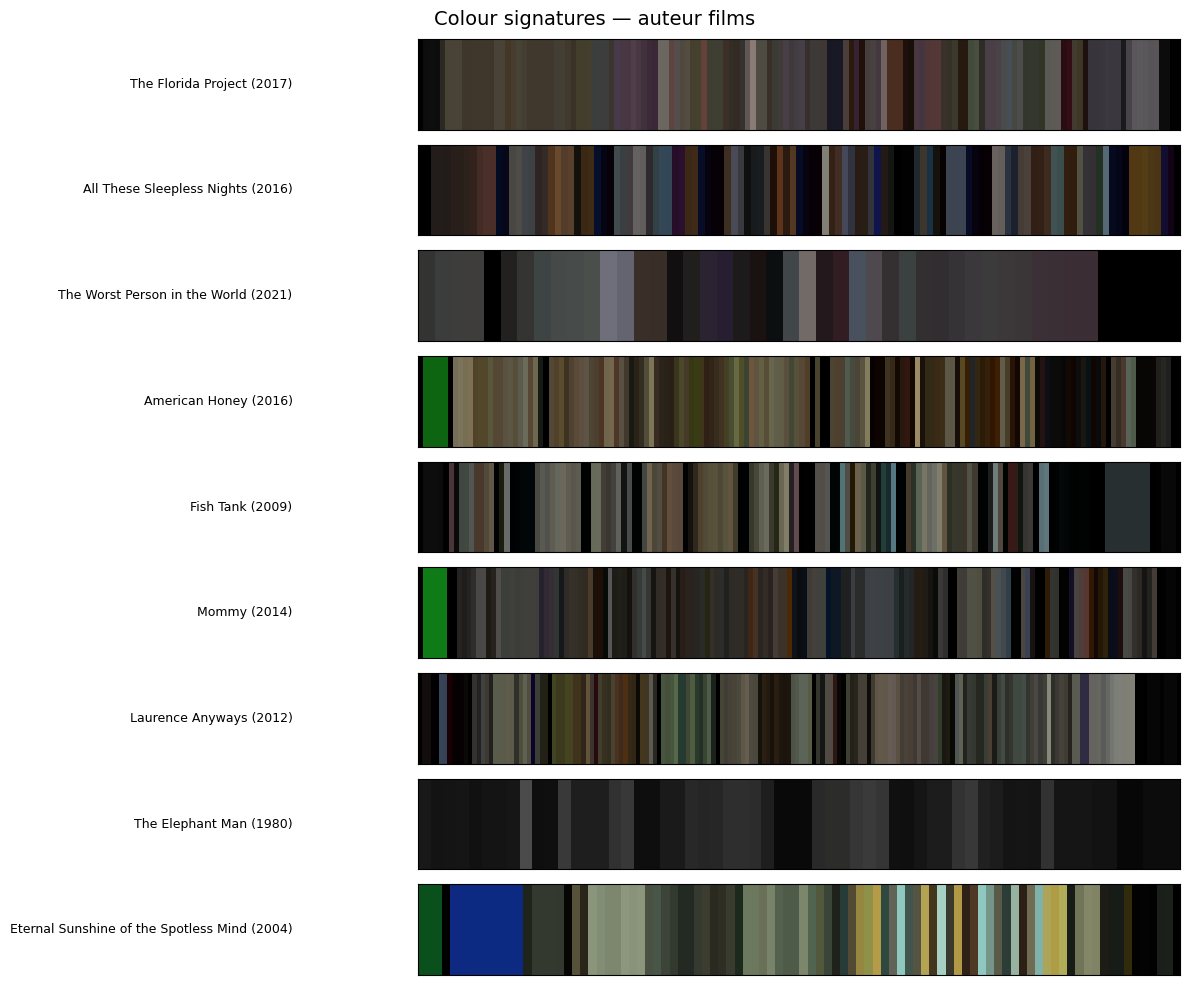

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(auteur_data), 1, figsize=(12, 10))

for i, film in enumerate(auteur_data):
    colours = film["colours"]
    immagine = np.array(colours).reshape(1, len(colours), 3)

    axes[i].imshow(immagine, aspect="auto")
    axes[i].set_yticks([])
    axes[i].set_xticks([])
    # titolo del film a sinistra
    etichetta = f"{film['titolo']} ({film['anno']})"
    axes[i].set_ylabel(etichetta, rotation=0, labelpad=90, va="center", ha="right", fontsize=9)

plt.suptitle("Colour signatures — auteur films", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/barcode_auteur.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
# ricarichiamo le funzioni aggiornate da metrics
import importlib
import src.metrics
importlib.reload(src.metrics)
from src.metrics import color_distribution

# proviamo su Eternal Sunshine (l'ultimo della lista)
film = auteur_data[-1]
print("Film:", film["titolo"])

# ci servono i frame di nuovo
from src.frames import extract_frames
tmdb_id = None
for f in risultati_autore:
    if f["titolo"] == film["titolo"]:
        tmdb_id = f["tmdb_id"]

frames = extract_frames(f"../data/raw/auteur_trailers/{tmdb_id}.mp4", per_second=1)
dist = color_distribution(frames)

print("Distribuzione colori:")
for famiglia, perc in dist.items():
    print(f"  {famiglia}: {round(perc*100)}%")

Film: Eternal Sunshine of the Spotless Mind
Distribuzione colori:
  red: 0%
  orange: 2%
  yellow: 14%
  green: 46%
  blue: 14%
  purple: 0%
  dark_neutral: 24%


In [1]:
import sys
sys.path.append("..")
from src.frames import extract_frames
from src.metrics import color_distribution

# 38 = Eternal Sunshine
frames = extract_frames("../data/raw/auteur_trailers/38.mp4", per_second=1)
dist = color_distribution(frames)
for famiglia, perc in dist.items():
    print(f"  {famiglia}: {round(perc*100)}%")

  red: 0%
  orange: 2%
  yellow: 14%
  green: 45%
  blue: 15%
  purple: 0%
  dark_neutral: 24%


In [3]:
print(len(auteur_data))
print(auteur_data[0].keys())

NameError: name 'auteur_data' is not defined

In [4]:
import sys
sys.path.append("..")
import os
import pandas as pd
import numpy as np
from src.frames import extract_frames
from src.metrics import curve_from_frames

# ricarichiamo la lista dei film d'autore salvata prima
autore_df = pd.read_csv("../data/source/auteur_films.csv")

cartella = "../data/raw/auteur_trailers"
auteur_data = []

for i, row in autore_df.iterrows():
    tmdb_id = row["tmdb_id"]
    percorso = f"{cartella}/{tmdb_id}.mp4"

    frames = extract_frames(percorso, per_second=1)
    brightness, temperature, saturation, colours = curve_from_frames(frames)

    auteur_data.append({
        "titolo": row["titolo"],
        "anno": row["anno"],
        "brightness_media": np.mean(brightness),
        "saturation_media": np.mean(saturation),
        "temperature_media": np.mean(temperature),
    })
    print("Fatto:", row["titolo"])

# salviamo su disco cosi non lo perdiamo piu
auteur_summary = pd.DataFrame(auteur_data)
auteur_summary.to_csv("../data/warehouse/auteur_features.csv", index=False)
print("\nSalvato:", len(auteur_summary), "film d'autore")
auteur_summary

Fatto: The Florida Project
Fatto: All These Sleepless Nights
Fatto: The Worst Person in the World
Fatto: American Honey
Fatto: Fish Tank
Fatto: Mommy
Fatto: Laurence Anyways
Fatto: The Elephant Man
Fatto: Eternal Sunshine of the Spotless Mind

Salvato: 9 film d'autore


,titolo,anno,brightness_media,saturation_media,temperature_media
0,The Florida Project,2017,23.929007,0.261833,3.410589
1,All These Sleepless Nights,2016,16.793929,0.496442,1.318113
2,The Worst Person in the World,2021,19.403259,0.215444,-0.546467
3,American Honey,2016,22.921178,0.361758,10.433601
4,Fish Tank,2009,20.495289,0.219573,3.722160
5,Mommy,2014,17.806199,0.213109,3.380779
6,Laurence Anyways,2012,22.547386,0.221710,5.121928
7,The Elephant Man,1980,11.789377,0.002909,0.017627
8,Eternal Sunshine of the Spotless Mind,2004,33.538844,0.452333,4.955138


In [5]:
print(len(auteur_data))
print(auteur_data[0].keys())

9
dict_keys(['titolo', 'anno', 'brightness_media', 'saturation_media', 'temperature_media'])


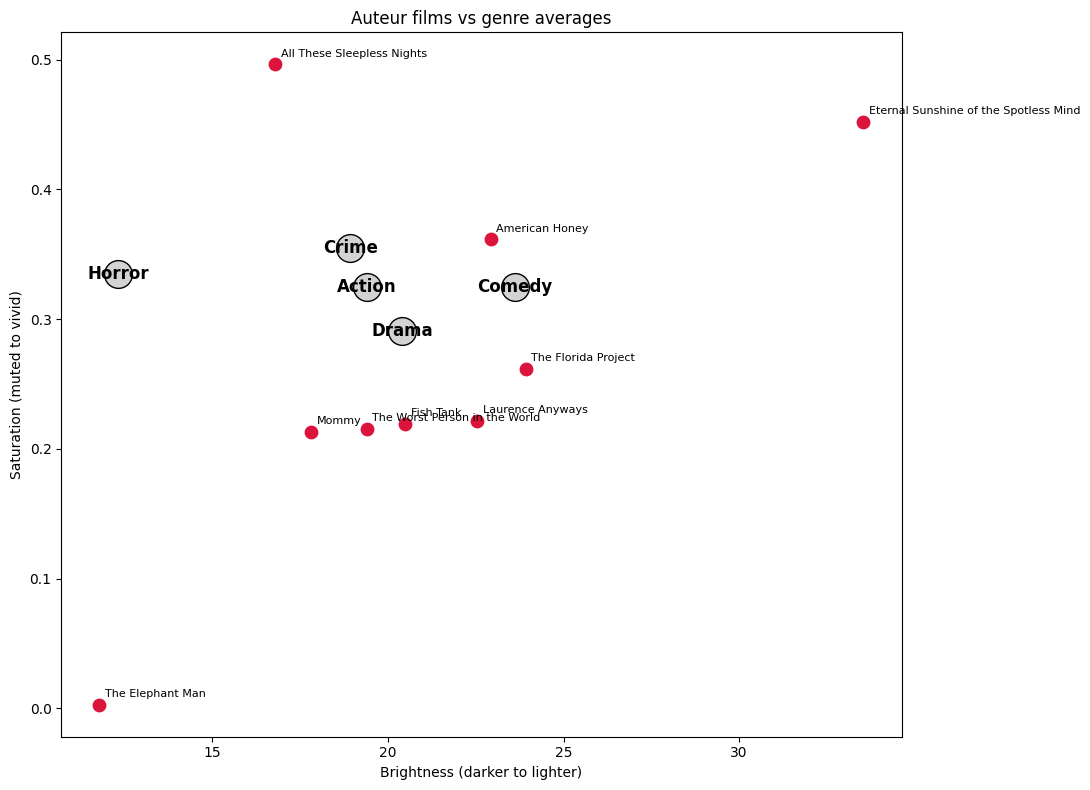

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

warehouse = pd.read_csv("../data/warehouse/color_features.csv")
generi_media = warehouse.groupby("genere_principale")[["brightness_media", "saturation_media"]].mean()

auteur = pd.DataFrame(auteur_data)

fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(generi_media["brightness_media"], generi_media["saturation_media"], s=400, c="lightgray", edgecolors="black", zorder=1)
for genere, riga in generi_media.iterrows():
    ax.annotate(genere, (riga["brightness_media"], riga["saturation_media"]), fontsize=12, fontweight="bold", ha="center", va="center")

ax.scatter(auteur["brightness_media"], auteur["saturation_media"], s=80, c="crimson", zorder=2)
for i, riga in auteur.iterrows():
    ax.annotate(riga["titolo"], (riga["brightness_media"], riga["saturation_media"]), fontsize=8, ha="left", va="bottom", xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("Brightness (darker to lighter)")
ax.set_ylabel("Saturation (muted to vivid)")
ax.set_title("Auteur films vs genre averages")
plt.tight_layout()
plt.savefig("../outputs/auteur_vs_genres.png", dpi=120, bbox_inches="tight")
plt.show()